# D06 · Let the response shape vary: FIR versus a fixed HRF

A canonical HRF model spends few parameters describing a response. That can improve precision when its shape is a reasonable approximation. A finite impulse response model, or FIR, instead estimates a separate coefficient for each lag after an event. FIR here means a collection of delayed event columns; it does not mean the scanner acquired more temporal resolution. Its coefficients still live on the chosen sampling grid and are subject to overlap, noise, and design identifiability.

Imagine that a participant's response peaks later than the canonical curve. A single amplitude coefficient cannot shift a fixed template. It may compromise by reducing its amplitude and leaving a systematic residual pattern. A temporal-derivative basis can approximate small timing changes; a broader FIR basis can represent more shapes at the cost of more parameters and potentially higher uncertainty. More flexible is not automatically better. We need to ask which quantity is primary: detecting an expected response, estimating a peak delay, or characterizing an unfamiliar time course.

The synthetic experiment contains isolated event onsets and a known eight-lag response. Because events do not overlap, the lag columns are particularly easy to understand. We first construct FIR columns without circular wrapping: an event shifted beyond the run disappears rather than reappearing at its start. We then generate a noiseless outcome from a delayed response and a baseline. A full-rank FIR model recovers every lag exactly. A fixed, incorrectly timed template cannot reproduce the same waveform with one scale coefficient.

This is a structural demonstration of model mismatch, not evidence that FIR wins in noisy real data. Repeated events with identical spacing, short runs, and excessive lag windows can create dependent or poorly conditioned columns. Real interpretation requires uncertainty on the estimated response, appropriate nuisance terms, filtering, and a temporal-noise model. Comparing raw training residual error favors models with more columns; compare predictive or inferential performance relevant to the planned question instead.

Each column predicts one lag. Verify that shifting has not wrapped events to the beginning of the run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
n, lags = 140, 8
events = np.zeros(n); events[[5, 25, 45, 65, 85, 105]] = 1
F = np.column_stack([np.r_[np.zeros(k), events[:n-k]] if k else events for k in range(lags)])
true_hrf = np.array([0., 0., .1, .5, 1., .7, .3, 0.])
canonical = np.array([0., .2, .8, 1., .5, .1, 0., 0.])
y = 10 + F @ true_hrf
X_fir = np.column_stack([np.ones(n), F])
X_can = np.column_stack([np.ones(n), F @ canonical])
b_fir = np.linalg.lstsq(X_fir, y, rcond=None)[0]
b_can = np.linalg.lstsq(X_can, y, rcond=None)[0]
assert np.linalg.matrix_rank(X_fir) == lags + 1
assert np.allclose(b_fir[1:], true_hrf)
assert np.allclose(F[:5], 0)

Compare systematic residual error, while keeping the noiseless nature of this demonstration explicit.

Noiseless residual sums of squares: 2.0415720227119786e-26 6.610938365650977


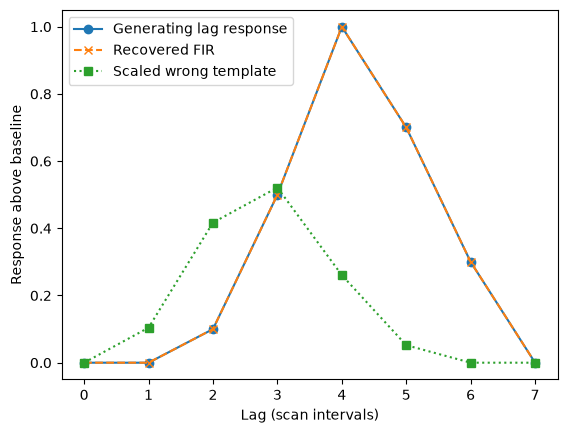

In [2]:
rss_fir = np.sum((y - X_fir @ b_fir) ** 2)
rss_can = np.sum((y - X_can @ b_can) ** 2)
assert rss_fir < 1e-20 and rss_can > 1
print('Noiseless residual sums of squares:', rss_fir, rss_can)
plt.plot(range(lags), true_hrf, 'o-', label='Generating lag response')
plt.plot(range(lags), b_fir[1:], 'x--', label='Recovered FIR')
plt.plot(range(lags), b_can[1] * canonical, 's:', label='Scaled wrong template')
plt.xlabel('Lag (scan intervals)'); plt.ylabel('Response above baseline')
plt.legend(); plt.show()
identical = np.column_stack([F[:, 1], F[:, 1]])
assert np.linalg.matrix_rank(identical) == 1

## Supervise the AI, then transfer the idea

**AI prompt:** “Explain the difference between one amplitude and eight lag coefficients. State the units of the lag axis. Show how a circular shift would introduce a false event at the run boundary. Add reproducible noise and discuss why exact FIR recovery should disappear; do not promise that more parameters improve unseen data.”

**Deliberate mistake:** choose FIR solely because its training error is lower. Repair the comparison with a prespecified target, adequate sampling, uncertainty, and a validation or model-comparison strategy. For a real workflow, identify the package's FIR delays, bin width, event-duration treatment, high-pass filter, and noise model. Contrast the whole response with an omnibus F test when appropriate rather than selecting the most positive lag after inspection. Deliver an annotated response curve and a decision about whether detection or shape estimation is the goal.

## Answer key — read after your own explanation

The FIR model recovers the generating lag coefficients exactly in this noiseless full-rank construction. The wrong fixed template leaves residual structure because scaling cannot shift its shape. More columns can always improve or preserve least-squares training fit, but can increase uncertainty. Lags are scan intervals here; converting to seconds requires TR. A duplicated lag column is non-identifiable even if a pseudoinverse returns numbers.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [Poldrack DesignEfficiency notebook, FIR estimation section](https://github.com/poldrack/fmri-analysis-vm/blob/d93fcf8e818c850d0a1b4e96b01ac987f27e9d34/analysis/efficiency/DesignEfficiency.ipynb); [SPM fMRI model specification, basis functions](https://www.fil.ion.ucl.ac.uk/spm/docs/manual/fmri_spec/fmri_spec/). See [the coverage and gaps](../../curriculum/design_coverage.md).